In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

In [2]:
base_dir = Path("experiment4_testing/layers_7_14_21/max_chars750000")
results = {}
for folder in base_dir.iterdir():
    if folder.is_dir() and folder.name.startswith("pca_comps_"):
        result_file = folder / "experimental_results.json"
        if result_file.exists():
            with open(result_file) as f:
                data = json.load(f)
                I = data["pca_comps_I"]
                O = data["pca_comps_O"]
                results[(I, O)] = data

In [3]:
I_values = sorted(set(k[0] for k in results.keys()))
O_values = sorted(set(k[1] for k in results.keys()))

perplexity_diff = np.full((len(I_values), len(O_values)), np.nan)

for i, I in enumerate(I_values):
    for j, O in enumerate(O_values):
        if (I, O) in results:
            data = results[(I, O)]
            baseline = data["baseline_perplexity_val"]
            intervened = data["intervened_perplexity_val"]
            perplexity_diff[i, j] = intervened - baseline

In [4]:
baseline

10.618621775614777

In [5]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

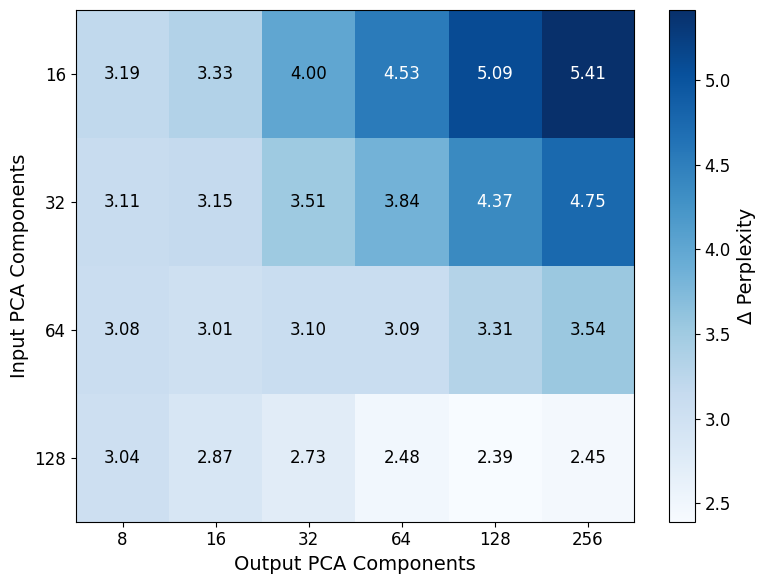

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(perplexity_diff, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(O_values)))
ax.set_yticks(range(len(I_values)))
ax.set_xticklabels(O_values)
ax.set_yticklabels(I_values)
ax.set_xlabel('Output PCA Components')
ax.set_ylabel('Input PCA Components')
# ax.set_title('Perplexity Difference on Validation (Intervened - Baseline)')

# Get colormap normalization
norm = im.norm
cmap = im.get_cmap()

for i in range(len(I_values)):
    for j in range(len(O_values)):
        if not np.isnan(perplexity_diff[i, j]):
            # Get normalized value and corresponding color
            norm_val = norm(perplexity_diff[i, j])
            rgba = cmap(norm_val)
            
            # Calculate luminance using the standard formula
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            
            # Use white text for dark backgrounds, black for light backgrounds
            text_color = 'white' if luminance < 0.5 else 'black'
            
            text = ax.text(j, i, f'{perplexity_diff[i, j]:.2f}', 
                           ha='center', va='center', color=text_color)
plt.colorbar(im, ax=ax, label='Δ Perplexity')
plt.tight_layout()
plt.savefig('figures/pca_results.png', dpi=300)
plt.show()

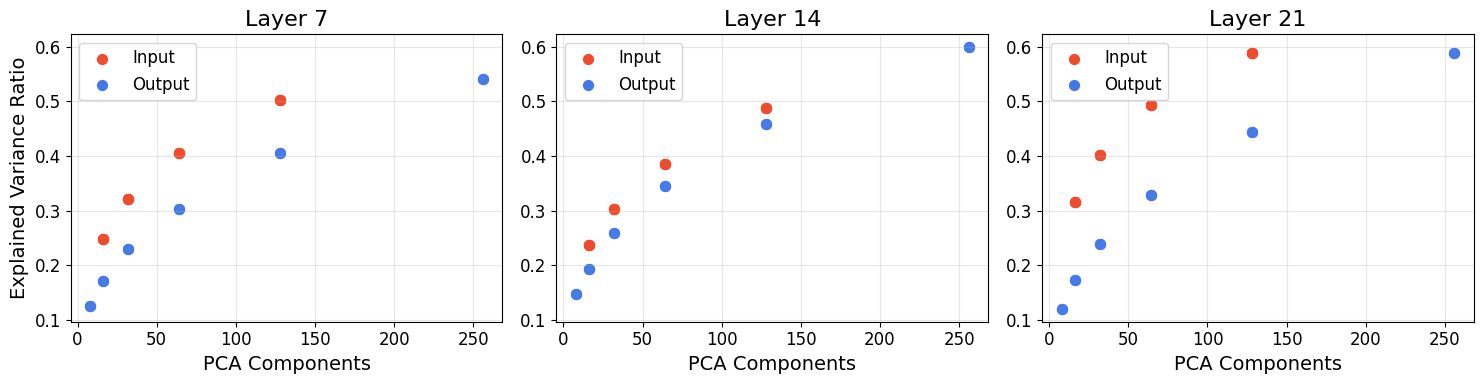

In [7]:
#SHOW EXPLAIND VARIANCE RATIO

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
layers = [7, 14, 21]

# First pass: collect all y-values to determine global y-axis limits
all_y_values = []
for I, O in results.keys():
    data = results[(I, O)]
    for layer in layers:
        layer_key = f"pca_layer{layer}"
        if layer_key in data:
            all_y_values.append(data[layer_key]["input_explained_var_ratio"])
            all_y_values.append(data[layer_key]["output_explained_var_ratio"])

y_min = min(all_y_values)
y_max = max(all_y_values)
y_margin = (y_max - y_min) * 0.05
y_lim = (y_min - y_margin, y_max + y_margin)

for idx, layer in enumerate(layers):
    ax = axes[idx]
    for I, O in results.keys():
        data = results[(I, O)]
        layer_key = f"pca_layer{layer}"
        if layer_key in data:
            ax.scatter(I, data[layer_key]["input_explained_var_ratio"], 
                       color='#EE4C2C', alpha=0.6, s=50)
            ax.scatter(O, data[layer_key]["output_explained_var_ratio"], 
                       color='#4478E8', alpha=0.6, s=50)
    
    ax.scatter([], [], color='#EE4C2C', label='Input', s=50)
    ax.scatter([], [], color='#4478E8', label='Output', s=50)
    ax.set_xlabel('PCA Components')
    
    # Only show y-axis label on the leftmost plot
    if idx == 0:
        ax.set_ylabel('Explained Variance Ratio')
    
    ax.set_title(f'Layer {layer}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set the same y-axis limits for all plots
    ax.set_ylim(y_lim)

plt.tight_layout()
plt.savefig('figures/explained_var_ratio.png', dpi = 300)
plt.show()

In [8]:
import pandas as pd

results_dir = Path("experiment7_results_runpod/experiment7_results")
experiment5_results = Path("experiment5/layers_7_14_21/max_chars750000/pca_comps_I32_O8/experimental_results.json")

# Load experiment5 perplexity data for original models
with open(experiment5_results) as f:
    exp5_data = json.load(f)

rows = []

# Process regular model folders (e.g., meta-llama_Llama-3.2-1B-Instruct_cuda_...)
for folder in results_dir.iterdir():
    if folder.is_dir() and "_cuda_" in folder.name and not folder.name.startswith("original_"):
        benchmark_file = folder / "benchmark.json"
        perplexity_file = folder / "perplexity.json"
        
        if benchmark_file.exists() and perplexity_file.exists():
            with open(benchmark_file) as f:
                benchmark = json.load(f)
            with open(perplexity_file) as f:
                perplexity = json.load(f)
            
            # Extract model name from folder name
            folder_parts = folder.name.split("_")
            model_name = "_".join(folder_parts[:2])
            
            rows.append({
                "model_name": model_name,
                "train_perplexity": perplexity["train_perplexity"],
                "val_perplexity": perplexity["val_perplexity"],
                "avg_latency_ms": benchmark["avg_latency_ms"],
                "p95_latency_ms": benchmark["p95_latency_ms"],
                "tokens_per_second": benchmark["tokens_per_second"],
                "total_time_sec": benchmark["total_time_sec"],
            })

# Process original_cuda folder (baseline, skip_mlp, symbolic)
for folder in results_dir.iterdir():
    if folder.is_dir() and folder.name.startswith("original_cuda_"):
        for model_type in ["baseline", "skip_mlp", "symbolic"]:
            benchmark_file = folder / f"{model_type}_benchmark.json"
            
            if benchmark_file.exists():
                with open(benchmark_file) as f:
                    benchmark = json.load(f)
                
                # Get perplexity from experiment5 results
                if model_type == "baseline":
                    train_ppl = exp5_data["baseline_perplexity_train"]
                    val_ppl = exp5_data["baseline_perplexity_val"]
                elif model_type == "symbolic":
                    train_ppl = exp5_data["intervened_perplexity_train"]
                    val_ppl = exp5_data["intervened_perplexity_val"]
                else:  # skip_mlp - no perplexity data available
                    train_ppl = None
                    val_ppl = None
                
                rows.append({
                    "model_name": model_type,
                    "train_perplexity": train_ppl,
                    "val_perplexity": val_ppl,
                    "avg_latency_ms": benchmark["avg_latency_ms"],
                    "p95_latency_ms": benchmark["p95_latency_ms"],
                    "tokens_per_second": benchmark["tokens_per_second"],
                    "total_time_sec": benchmark["total_time_sec"],
                })

df = pd.DataFrame(rows)
df

,model_name,train_perplexity,val_perplexity,avg_latency_ms,p95_latency_ms,tokens_per_second,total_time_sec
0,HuggingFaceTB_SmolLM2-1.7B-Instruct,10.061853,10.332439,240.475276,240.890366,4258.234020,24.047528
1,Qwen_Qwen2.5-7B-Instruct,8.732422,8.867678,866.061449,867.713013,1182.364140,86.606145
2,Qwen_Qwen2.5-1.5B,10.240393,10.104848,209.188961,210.186050,4895.095782,20.918896
3,google_gemma-3-1b-it,51.504109,72.909514,145.041953,146.182846,7060.026275,14.504195
4,Qwen_Qwen2.5-3B-Instruct,9.854075,9.906988,397.848793,401.553589,2573.842170,39.784879
5,Qwen_Qwen2.5-0.5B-Instruct,15.619416,14.995303,76.754141,77.259453,13341.299708,7.675414
6,google_gemma-3-4b-it,51.902603,111.262946,471.673689,472.107666,2170.992414,47.167369
7,HuggingFaceTB_SmolLM3-3B,10.081031,10.201380,392.885965,393.522125,2606.354238,39.288596
8,TinyLlama_TinyLlama-1.1B-Chat-v1.0,11.375315,14.796788,148.995820,149.438950,6872.676039,14.899582
9,meta-llama_Llama-3.2-3B-Instruct,11.995423,12.318068,414.514177,416.034271,2470.361826,41.451418


In [9]:
df_res = df[df["model_name"] != "skip_mlp"]
df_res = df_res[df_res["model_name"] != "Qwen_Qwen2.5-1.5B"]
df_res = df_res[df_res["model_name"] != "Qwen_Qwen2.5-0.5B-Instruct"]

In [55]:
df_res.loc[df_res["model_name"] == "baseline", "model_name"] = "Qwen_Qwen2.5-1.5B-Instruct (Baseline)"
df_res.loc[df_res["model_name"] == "symbolic", "model_name"] = "Qwen_Qwen2.5-1.5B-Instruct (Symbolic)"

In [56]:
df_res

,model_name,train_perplexity,val_perplexity,avg_latency_ms,p95_latency_ms,tokens_per_second,total_time_sec
0,HuggingFaceTB_SmolLM2-1.7B-Instruct,10.061853,10.332439,240.475276,240.890366,4258.234020,24.047528
1,Qwen_Qwen2.5-7B-Instruct,8.732422,8.867678,866.061449,867.713013,1182.364140,86.606145
3,google_gemma-3-1b-it,51.504109,72.909514,145.041953,146.182846,7060.026275,14.504195
4,Qwen_Qwen2.5-3B-Instruct,9.854075,9.906988,397.848793,401.553589,2573.842170,39.784879
6,google_gemma-3-4b-it,51.902603,111.262946,471.673689,472.107666,2170.992414,47.167369
7,HuggingFaceTB_SmolLM3-3B,10.081031,10.201380,392.885965,393.522125,2606.354238,39.288596
8,TinyLlama_TinyLlama-1.1B-Chat-v1.0,11.375315,14.796788,148.995820,149.438950,6872.676039,14.899582
9,meta-llama_Llama-3.2-3B-Instruct,11.995423,12.318068,414.514177,416.034271,2470.361826,41.451418
10,meta-llama_Llama-3.1-8B-Instruct,8.075438,8.518056,891.843672,892.893005,1148.183288,89.184367
11,meta-llama_Llama-3.2-1B-Instruct,14.118601,14.212418,169.306889,170.077438,6048.188639,16.930689


In [145]:
100*(5281.416042-4878.822608)/4878.822608

8.251856366735918

In [57]:
df_res0 = df_res[df_res["model_name"] != "google_gemma-3-4b-it"]
df_res0 = df_res0[df_res0["model_name"] != "google_gemma-3-1b-it"]


In [58]:
from adjustText import adjust_text

def clean_model_name(name):
    """Remove the prefix before the underscore (e.g., 'Qwen_Qwen2.5' -> 'Qwen2.5')"""
    if "_" in name and name not in ["baseline", "skip_mlp", "symbolic"]:
        return name.split("_", 1)[1]
    return name

In [81]:
# fig, ax = plt.subplots(figsize=(12, 8))
# from matplotlib.ticker import FuncFormatter

# x_data = df_res0["val_perplexity"].values
# y_data = df_res0["tokens_per_second"].values
# labels = [clean_model_name(n) for n in df_res0["model_name"].values]

# # Plot points
# ax.scatter(x_data, y_data, s=100, color='#2563eb', edgecolor='white', linewidth=2, zorder=5)
# ax.scatter(x_data, y_data, s=150, color='#d1d5db', linewidth=3, zorder=4)

# # Add padding to axes
# x_range = x_data.max() - x_data.min()
# y_range = y_data.max() - y_data.min()
# ax.set_xlim(x_data.min() - 0.25 * x_range, x_data.max() + 0.15 * x_range)
# ax.set_ylim(y_data.min() - 0.2 * y_range, y_data.max() + 0.2 * y_range)

# # Create text objects (not annotations) for adjust_text
# texts = []
# ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.1f}'))

# for x, y, label, model_name in zip(x_data, y_data, labels, df_res0["model_name"].values):
#     # Special positioning for Qwen model
#     if model_name == "Qwen_Qwen2.5-7B-Instruct":
#         offset = (50, 5)
#     elif model_name == "meta-llama_Llama-3.1-8B-Instruct" or model_name == "Qwen_Qwen2.5-3B-Instruct":
#         offset = (-50,-20)
#     elif model_name == "HuggingFaceTB_SmolLM3-3B":
#         offset = (25,5)
#     else:
#         offset = (0, 5)
    
#     t = ax.annotate(
#         label,
#         xy=(x, y),
#         xytext=offset,  # ← Use variable offset
#         textcoords='offset points',
#         fontsize=12, 
#         fontweight='medium', 
#         ha='center', 
#         va='bottom',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
#                  edgecolor='#d1d5db', linewidth=1, alpha=0.95), 
#         zorder=4
#     )
#     texts.append(t)



# ax.set_xlabel("Validation Perplexity", fontsize=15, fontweight='medium')
# ax.set_ylabel(r"Throughput (1k tokens/s)", fontsize=15, fontweight='medium')
# ax.tick_params(axis='both', labelsize=11)
# ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='#e5e7eb')
# ax.set_axisbelow(True)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#d1d5db')
# ax.spines['bottom'].set_color('#d1d5db')
# plt.tight_layout()
# plt.savefig('figures/benchmark_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.show()

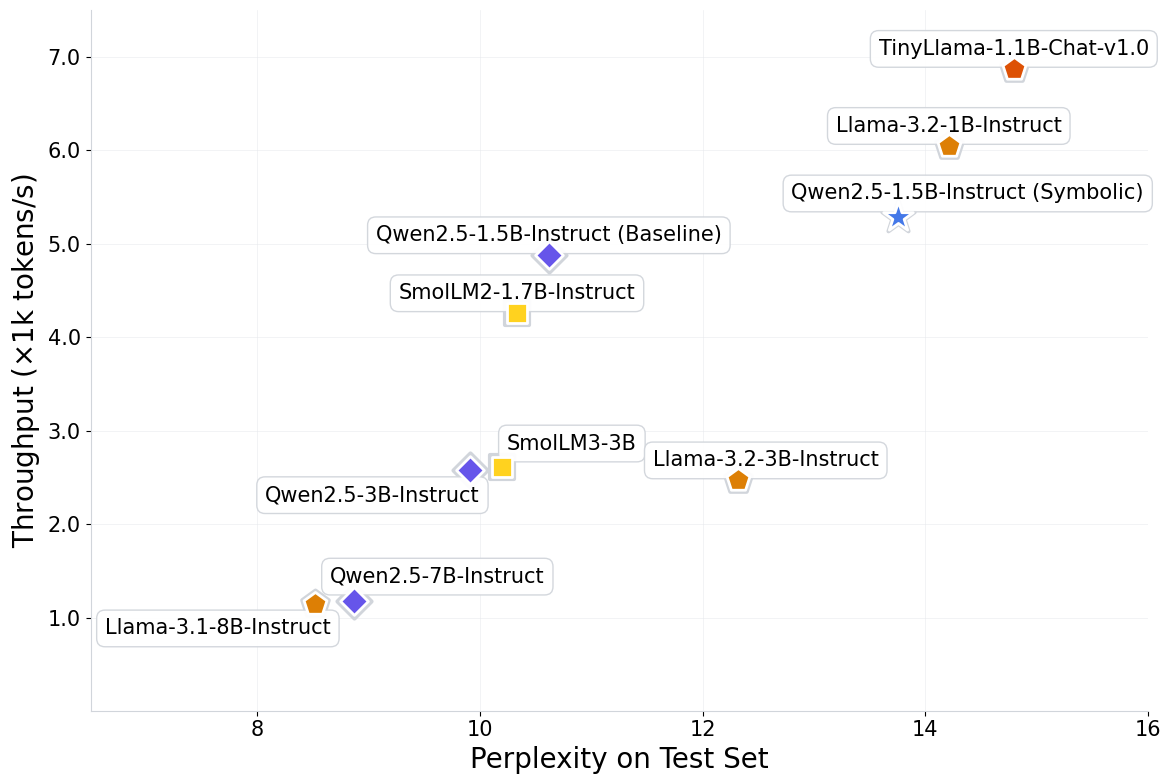

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
from matplotlib.ticker import FuncFormatter

x_data = df_res0["val_perplexity"].values
y_data = df_res0["tokens_per_second"].values
labels = [clean_model_name(n) for n in df_res0["model_name"].values]

# Plot points with different styles for specific models
for i, (x, y, model_name) in enumerate(zip(x_data, y_data, df_res0["model_name"].values)):
    if "Qwen" in model_name and ("Symbolic" not in model_name):
        base_size = 200
        ax.scatter(x, y, s=base_size + 100, facecolor = 'white', edgecolors='#d1d5db', linewidth=3, zorder=4, marker = "D")
        ax.scatter(x, y, s=base_size, color='#6655ea', edgecolor='white', linewidth=2, zorder=5, marker = "D") 
    elif "llama" in model_name:
        base_size = 300
        ax.scatter(x, y, s=base_size + 100, facecolor = 'white', edgecolors='#d1d5db', linewidth=3, zorder=4, marker = "p")
        ax.scatter(x, y, s=base_size, color="#dd7f05", edgecolor='white', linewidth=2, zorder=5, marker = "p") 

    elif "TinyLlama" in model_name:
        base_size = 300
        ax.scatter(x, y, s=base_size + 100, facecolor = 'white', edgecolors='#d1d5db', linewidth=3, zorder=4, marker = "p")
        ax.scatter(x, y, s=base_size , color="#dd5105", edgecolor='white', linewidth=2, zorder=5, marker = "p") 
    elif "Smol" in model_name:
        base_size = 200
        ax.scatter(x, y, s=base_size + 100, facecolor = 'white', edgecolors='#d1d5db', linewidth=3, zorder=4, marker = "s")
        ax.scatter(x, y, s=base_size, color="#ffd21f", edgecolor='white', linewidth=2, zorder=5, marker = "s") 
    else:
        base_size = 500
        ax.scatter(x, y, s=base_size+100, facecolor = 'white', edgecolors='#d1d5db', linewidth=3, zorder=4, marker = "*")
        ax.scatter(x, y, s=base_size, color='#4478E8', edgecolor='white', linewidth=2, zorder=5, marker ="*")

# Add padding to axes
x_range = x_data.max() - x_data.min()
y_range = y_data.max() - y_data.min()
# ax.set_xlim(x_data.min() - 0.25 * x_range, x_data.max() + 0.15 * x_range)
ax.set_xlim(6.5, 16)
# ax.set_ylim(y_data.min() - 0.2 * y_range, y_data.max() + 0.2 * y_range)
ax.set_ylim(y_data.min() - 0.2 * y_range, 7.5*1000)

# Create text objects (not annotations) for adjust_text
texts = []
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.1f}'))

for x, y, label, model_name in zip(x_data, y_data, labels, df_res0["model_name"].values):
    # Special positioning for Qwen model
    if model_name == "Qwen_Qwen2.5-7B-Instruct":
        offset = (60, 10)
    elif model_name == "meta-llama_Llama-3.1-8B-Instruct" or model_name == "Qwen_Qwen2.5-3B-Instruct":
        offset = (-70,-25)
    elif model_name == "meta-llama_Llama-3.2-3B-Instruct":
        offset = (20, 7)
    elif model_name == "HuggingFaceTB_SmolLM3-3B":
        offset = (50,10)
    elif "Symbolic" in model_name:
        offset = (50, 10)
    else:
        offset = (0, 7)
    
    t = ax.annotate(
        label,
        xy=(x, y),
        xytext=offset,
        textcoords='offset points',
        fontsize=15, 
        fontweight='medium', 
        ha='center', 
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                 edgecolor='#d1d5db', linewidth=1, alpha=0.95), 
        zorder=4
    )
    texts.append(t)

ax.set_xlabel("Perplexity on Test Set", fontsize=20, fontweight='medium')
ax.set_ylabel(r"Throughput ($\times1$k tokens/s)", fontsize=20, fontweight='medium')
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, alpha=0.7, linestyle='-', linewidth=0.5, color='#e5e7eb')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d1d5db')
ax.spines['bottom'].set_color('#d1d5db')
plt.tight_layout()
plt.savefig('figures/benchmark_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [23]:
df_res0["model_name"].values

array(['HuggingFaceTB_SmolLM2-1.7B-Instruct', 'Qwen_Qwen2.5-7B-Instruct',
       'Qwen_Qwen2.5-3B-Instruct', 'HuggingFaceTB_SmolLM3-3B',
       'TinyLlama_TinyLlama-1.1B-Chat-v1.0',
       'meta-llama_Llama-3.2-3B-Instruct',
       'meta-llama_Llama-3.1-8B-Instruct',
       'meta-llama_Llama-3.2-1B-Instruct', 'baseline', 'symbolic'],
      dtype=object)

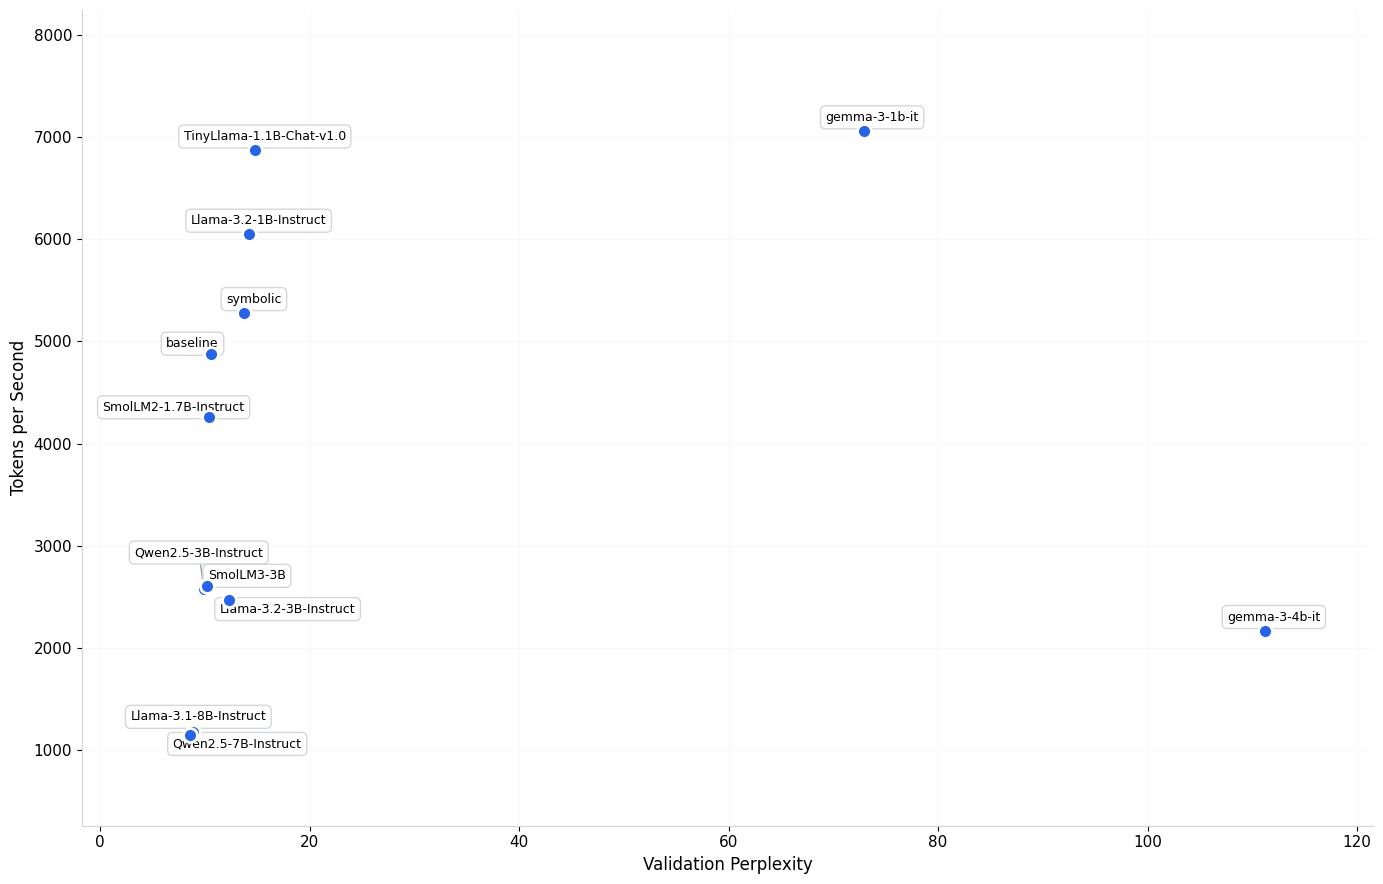

In [14]:
fig, ax = plt.subplots(figsize=(14, 9))

x_data = df_res["val_perplexity"].values
y_data = df_res["tokens_per_second"].values
labels = [clean_model_name(n) for n in df_res["model_name"].values]

# Plot points
ax.scatter(x_data, y_data, s=100, color='#2563eb', edgecolor='white', linewidth=2, zorder=5)

# Add padding to axes
x_range = x_data.max() - x_data.min()
y_range = y_data.max() - y_data.min()
ax.set_xlim(x_data.min() - 0.1 * x_range, x_data.max() + 0.1 * x_range)
ax.set_ylim(y_data.min() - 0.15 * y_range, y_data.max() + 0.2 * y_range)

# Create text objects (not annotations) for adjust_text
texts = []
for x, y, label in zip(x_data, y_data, labels):
    t = ax.text(x, y, label, fontsize=9, fontweight='medium', ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='#d1d5db', linewidth=1, alpha=0.95), zorder=4)
    texts.append(t)

adjust_text(
    texts,
    x=x_data,
    y=y_data,
    ax=ax,
    force_text=(1.5, 2.5),
    force_points=(2.0, 2.5),
    expand_points=(2.0, 2.0),
    expand_text=(1.3, 1.3),
    lim=3000,
    only_move={'points': 'y', 'text': 'xy'},
    arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=1),
)

ax.set_xlabel("Validation Perplexity", fontsize=12, fontweight='medium')
ax.set_ylabel("Tokens per Second", fontsize=12, fontweight='medium')
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5, color='#e5e7eb')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#d1d5db')
ax.spines['bottom'].set_color('#d1d5db')
plt.tight_layout()
plt.savefig('figures/benchmark_comparison_full.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()